# 位置情報データチェックと気象データ取得準備
- カヤノ農産のデータ
- 作物はお茶

In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import ast
import matplotlib.pyplot as plt

In [2]:
### 変数設定 ###
farm_dir = 'farm'
# #--当初のデータ
# farm_excel = '【confidential】サンプルデータ　カヤノ農産様.xlsx'
# excel_sheet = 'カヤノ農産様　データ'
#--追加のデータ（通常のxlsxフォーマット変換後）
farm_excel = '【Confidential】サンプルデータ_カヤノ農産様_251203.xlsx'
excel_sheet = 'カヤノ農産様'
farm_file = 'kayano_farm.csv'
gpkg_file = 'kayano_farm.gpkg'
gpkg_layer = 'kayano_farm'

- 追加のデータ『【Confidential】サンプルデータ　カヤノ農産様　251203.xlsx』は『Strict Open XML スプレッドシート』という特殊な形式になっている
- そのままでは読み込みに失敗するため、Excelから「名前をつけて保存」で通常のExcelフォーマット(xlsx)に変換する必要がある
- なお本ノートブックの処理結果は新旧データで変化ない

## 農場テーブル作成
- 圃場名とポリゴン情報は1対1に対応
- Excelファイルの「Sheet1」には品種名が記載されている
    - 「カヤノ農産様　データ」から農場テーブルを作成する

In [3]:
#--Excelファイル読み込み
df_org = pd.read_excel(f'{farm_dir}/{farm_excel}', sheet_name=excel_sheet)
df_org.dropna(inplace=True)
df_org.head()

,栽培グループ名,年度,圃場名,polygon,定植日,収穫日,経過日,NDVI値
0,カヤノ農産,2021,1_カヤノ農産,"[[33.36599694173723, 131.44292205671238], [33....",2021-01-01,2021-12-31,0,0.000000
1,カヤノ農産,2021,1_カヤノ農産,"[[33.36599694173723, 131.44292205671238], [33....",2021-01-01,2021-12-31,5,0.000000
2,カヤノ農産,2021,1_カヤノ農産,"[[33.36599694173723, 131.44292205671238], [33....",2021-01-01,2021-12-31,10,0.000000
3,カヤノ農産,2021,1_カヤノ農産,"[[33.36599694173723, 131.44292205671238], [33....",2021-01-01,2021-12-31,15,0.000000
4,カヤノ農産,2021,1_カヤノ農産,"[[33.36599694173723, 131.44292205671238], [33....",2021-01-01,2021-12-31,20,0.849886


In [4]:
#--圃場名とポリゴンがユニークか確認
print("圃場名とポリゴンで重複を削除", df_org.drop_duplicates(subset=['圃場名','polygon']).shape )
print("圃場名のユニーク数", len(df_org['圃場名'].unique()) )
print("ポリゴンのユニーク数", len(df_org['polygon'].unique()) )

圃場名とポリゴンで重複を削除 (34, 8)
圃場名のユニーク数 34
ポリゴンのユニーク数 34


In [5]:
#--農場データフレーム作成
colnames = ['栽培グループ名', '圃場名', 'polygon']
df_farm = df_org[colnames].drop_duplicates(subset=['圃場名','polygon']).reset_index(drop=True)
# df_farm.to_csv(f"{farm_dir}/{farm_file}", index=False)

In [ ]:
# def convert_to_polygon(geom_str):
#     coords_list = ast.literal_eval(geom_str)  # 文字列をリストに safely 変換
#     return Polygon(coords_list)  # 最外周の1つ目のリング（穴がなければこれだけでOK）

# # ast.literal_eval は安全に文字列 → Pythonリストに変換できます（evalは使わないでください）。
# # ポリゴンの穴（内側リング）がある場合は Polygon(outer_ring, [hole1, hole2, ...]) のように加工が必要です。

# df["geometry"] = df["polygon"].apply(convert_to_polygon)
# df.head()

In [6]:
#--ポリゴンのテキスト情報を地理情報フォーマットに変換
def make_polygon(geom_str):
    coords_latlon = ast.literal_eval(geom_str)
    #--lat,lon の順番を、lon,latに変える
    coords_lonlat = [(lon, lat) for lat, lon in coords_latlon]
    return Polygon(coords_lonlat)

df_farm["geometry"] = df_farm["polygon"].apply(make_polygon)
df_farm.head()

,栽培グループ名,圃場名,polygon,geometry
0,カヤノ農産,1_カヤノ農産,"[[33.36599694173723, 131.44292205671238], [33....",POLYGON ((131.44292205671238 33.36599694173723...
1,カヤノ農産,10_カヤノ農産,"[[33.364463009425776, 131.4418705852136], [33....",POLYGON ((131.4418705852136 33.364463009425776...
2,カヤノ農産,11_カヤノ農産,"[[33.36421981530506, 131.44149476766682], [33....",POLYGON ((131.44149476766682 33.36421981530506...
3,カヤノ農産,12_カヤノ農産,"[[33.36476243743253, 131.4409786781593], [33.3...","POLYGON ((131.4409786781593 33.36476243743253,..."
4,カヤノ農産,13_カヤノ農産,"[[33.365309470212786, 131.44040877018188], [33...",POLYGON ((131.44040877018188 33.36530947021278...


In [7]:
#--GeoDataFrameに変換
gdf_farm = gpd.GeoDataFrame(df_farm, geometry="geometry", crs="EPSG:4326")
gdf_farm.head()

,栽培グループ名,圃場名,polygon,geometry
0,カヤノ農産,1_カヤノ農産,"[[33.36599694173723, 131.44292205671238], [33....","POLYGON ((131.44292 33.366, 131.44242 33.36559..."
1,カヤノ農産,10_カヤノ農産,"[[33.364463009425776, 131.4418705852136], [33....","POLYGON ((131.44187 33.36446, 131.44158 33.364..."
2,カヤノ農産,11_カヤノ農産,"[[33.36421981530506, 131.44149476766682], [33....","POLYGON ((131.44149 33.36422, 131.44099 33.363..."
3,カヤノ農産,12_カヤノ農産,"[[33.36476243743253, 131.4409786781593], [33.3...","POLYGON ((131.44098 33.36476, 131.44045 33.364..."
4,カヤノ農産,13_カヤノ農産,"[[33.365309470212786, 131.44040877018188], [33...","POLYGON ((131.44041 33.36531, 131.43981 33.364..."


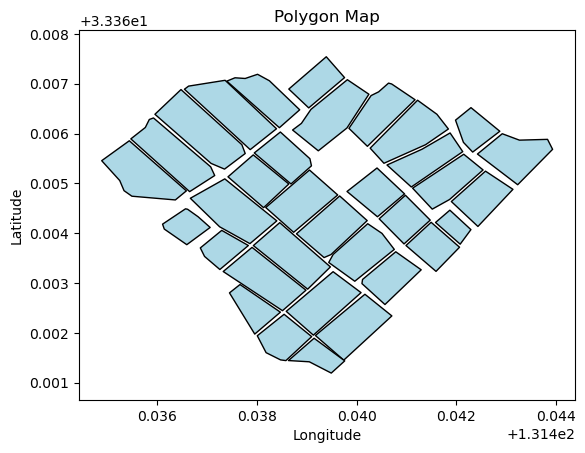

In [8]:
#--可視化を試す
gdf_farm.plot(edgecolor='black', facecolor='lightblue')
plt.title("Polygon Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal') # スケールを揃える
plt.show()

In [ ]:
#--GeoPackage形式で出力
# gdf_farm.to_file(f"{farm_dir}/{gpkg_file}", driver='GPKG', layer=gpkg_layer, encoding='utf-8')

In [9]:
#--各ポリゴンの重心位置を計算
latitude = []
longitude = []
for i, row in gdf_farm.iterrows():
    center = list(row['geometry'].centroid.coords)[0]
    longitude.append(center[0])
    latitude.append(center[1])

gdf_farm["longitude"] = longitude
gdf_farm["latitude"] = latitude

In [10]:
#--便宜上、圃場ごとの固有IDをつける
gdf_farm['field_id'] = gdf_farm['圃場名'].str.split('_').apply(lambda x: f"kayano{int(x[0]):02d}")

#--緯度経度情報を含めてCSV出力
col_order = ['field_id', '栽培グループ名', '圃場名', 'longitude', 'latitude', 'polygon']
gdf_farm[col_order].to_csv(f"{farm_dir}/{farm_file}", index=False)